Libraries loaded successfully
Shape : (1916, 37)
=== Descriptive stats by debt_crisis ===
               age  total_income  total_debt   dsr  annual_interest  \
debt_crisis                                                           
0            30.55       3409.59     7031.22  0.06           158.36   
1            28.45       1908.33    18165.11  1.59           752.91   

             annual_repayment  
debt_crisis                    
0                       71.00  
1                     1469.35  


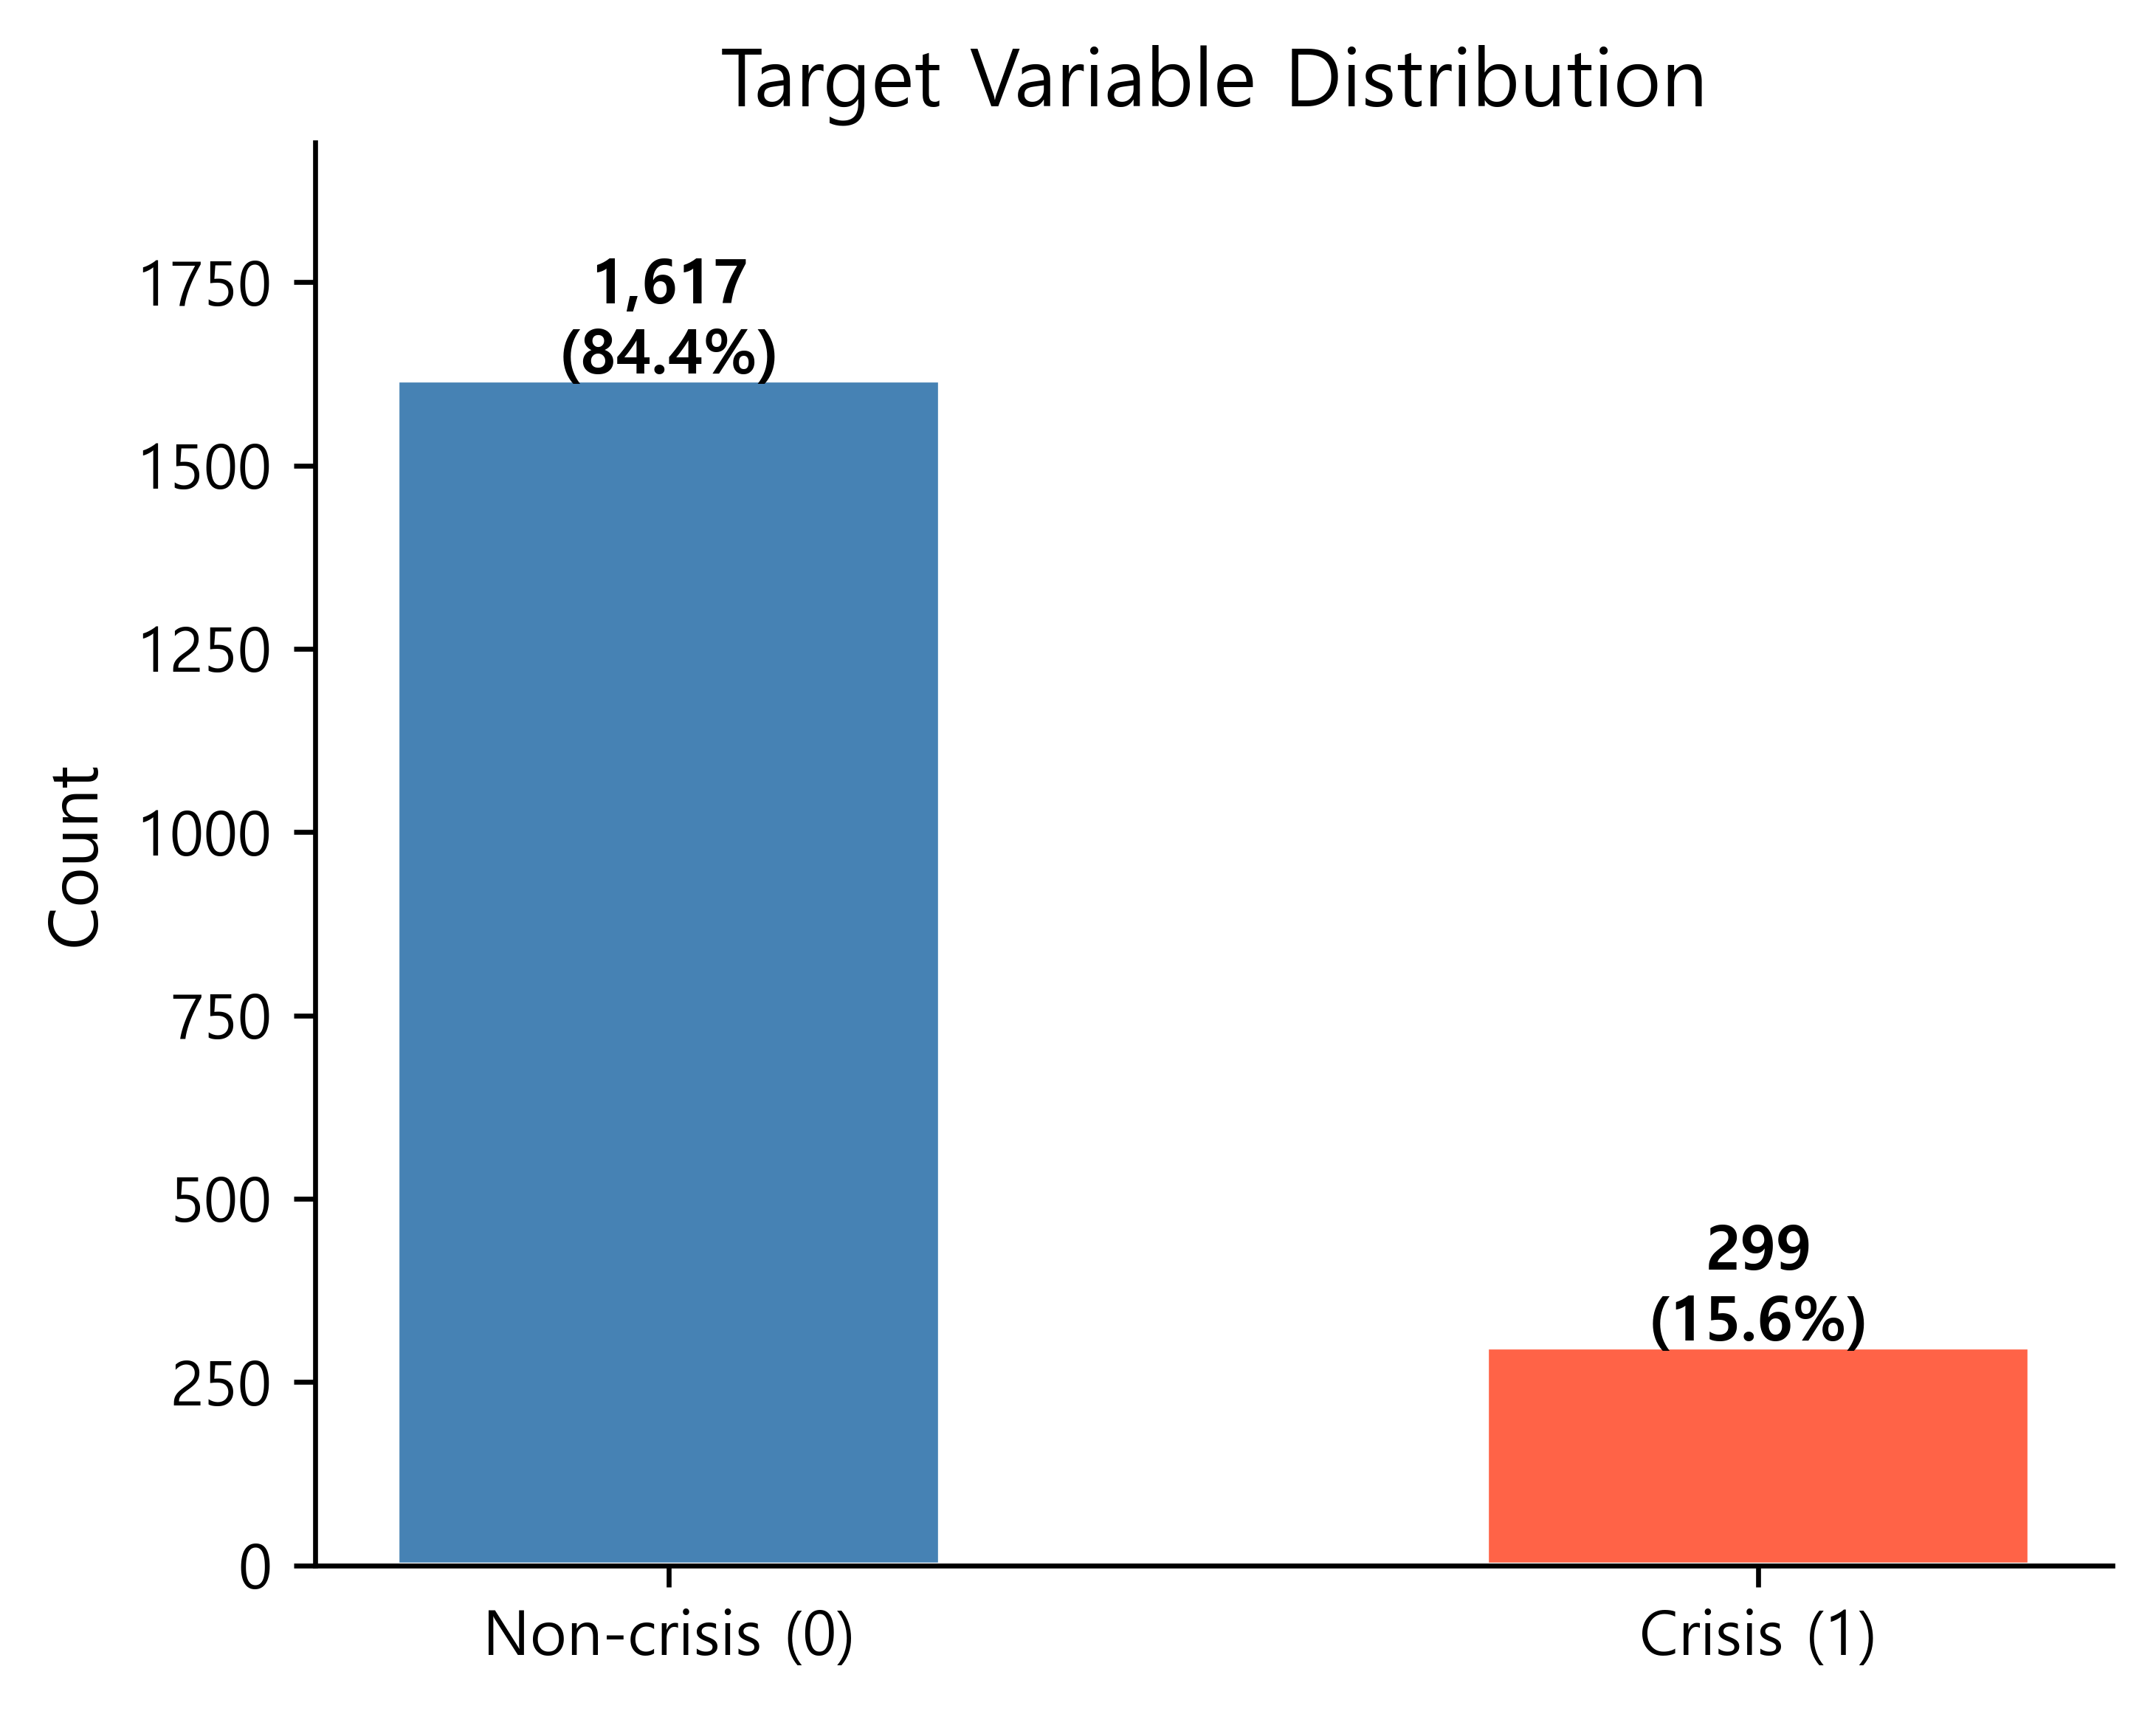

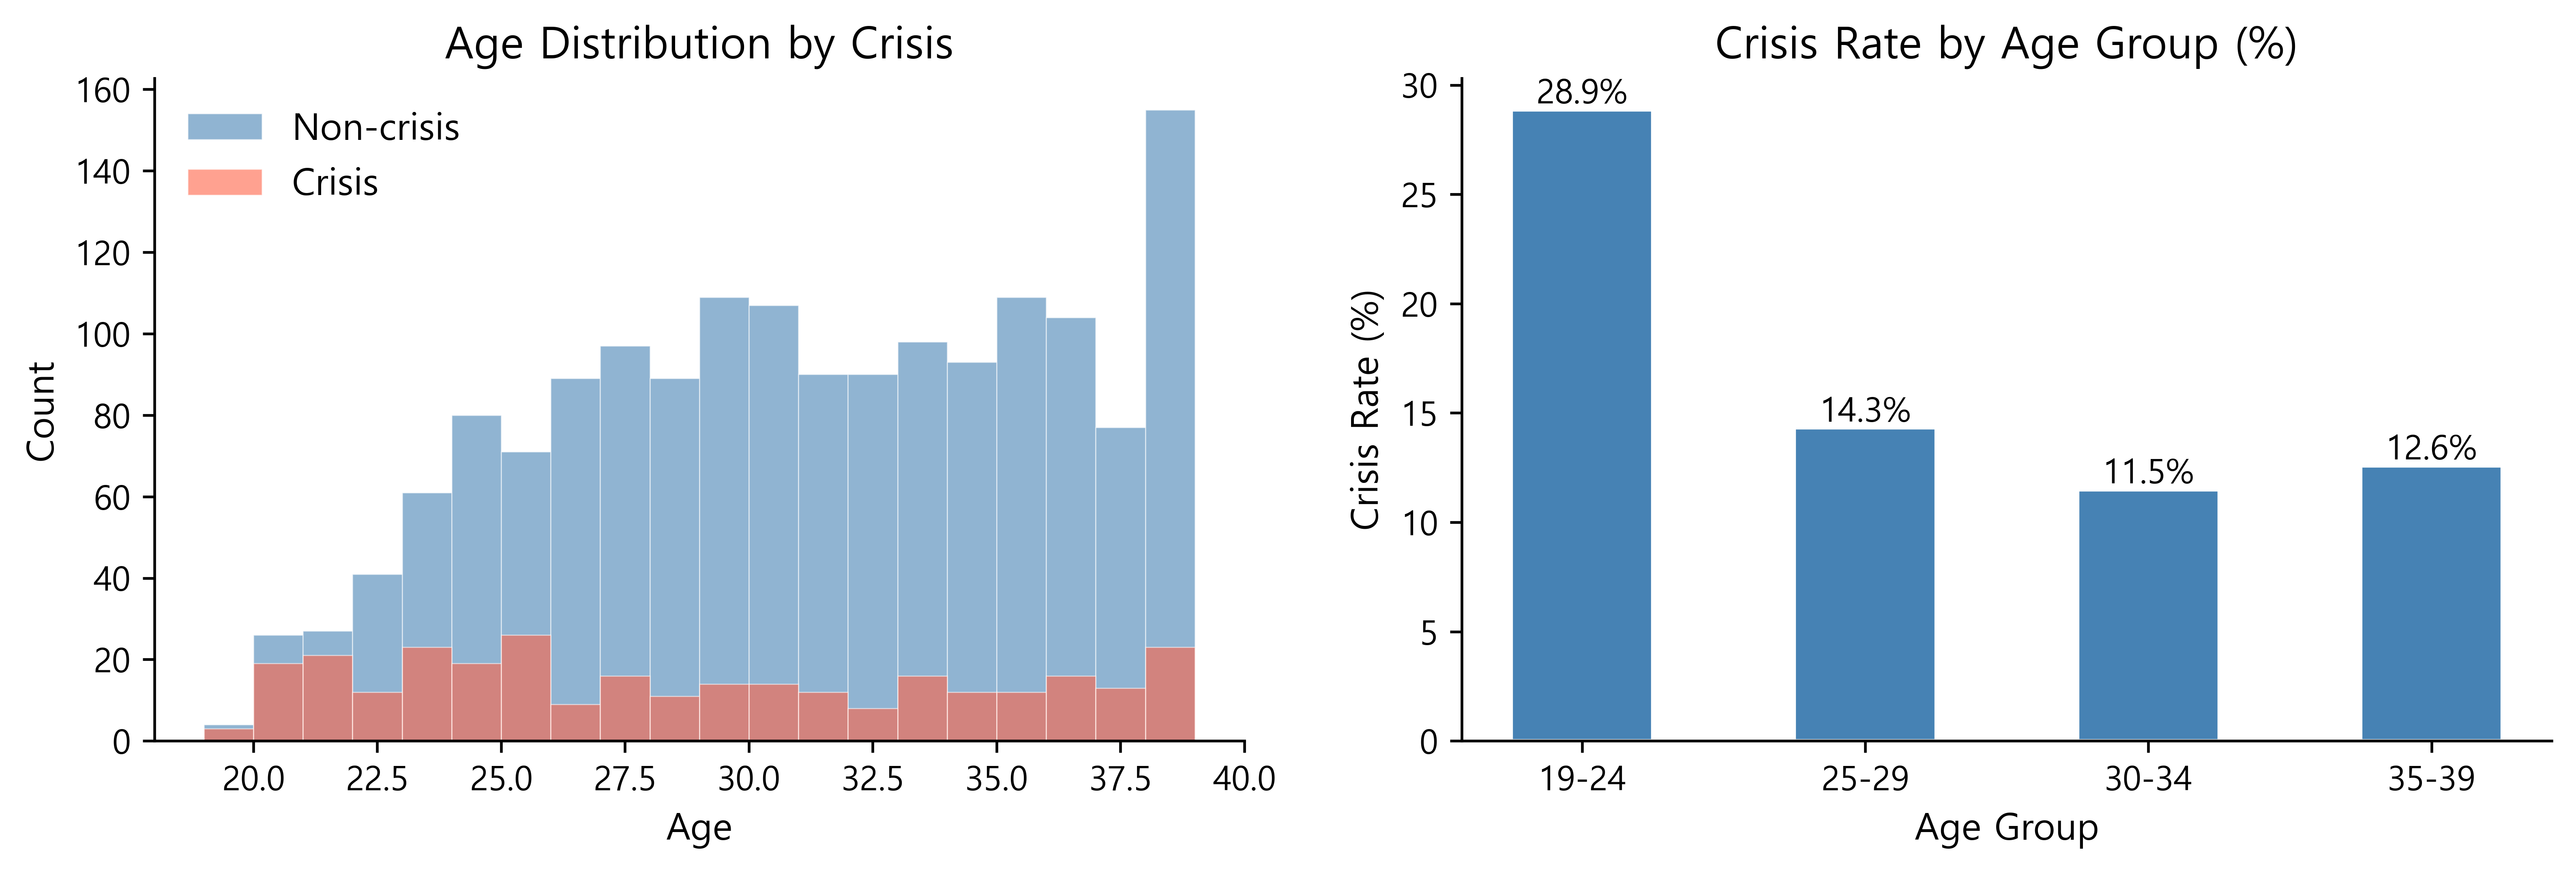

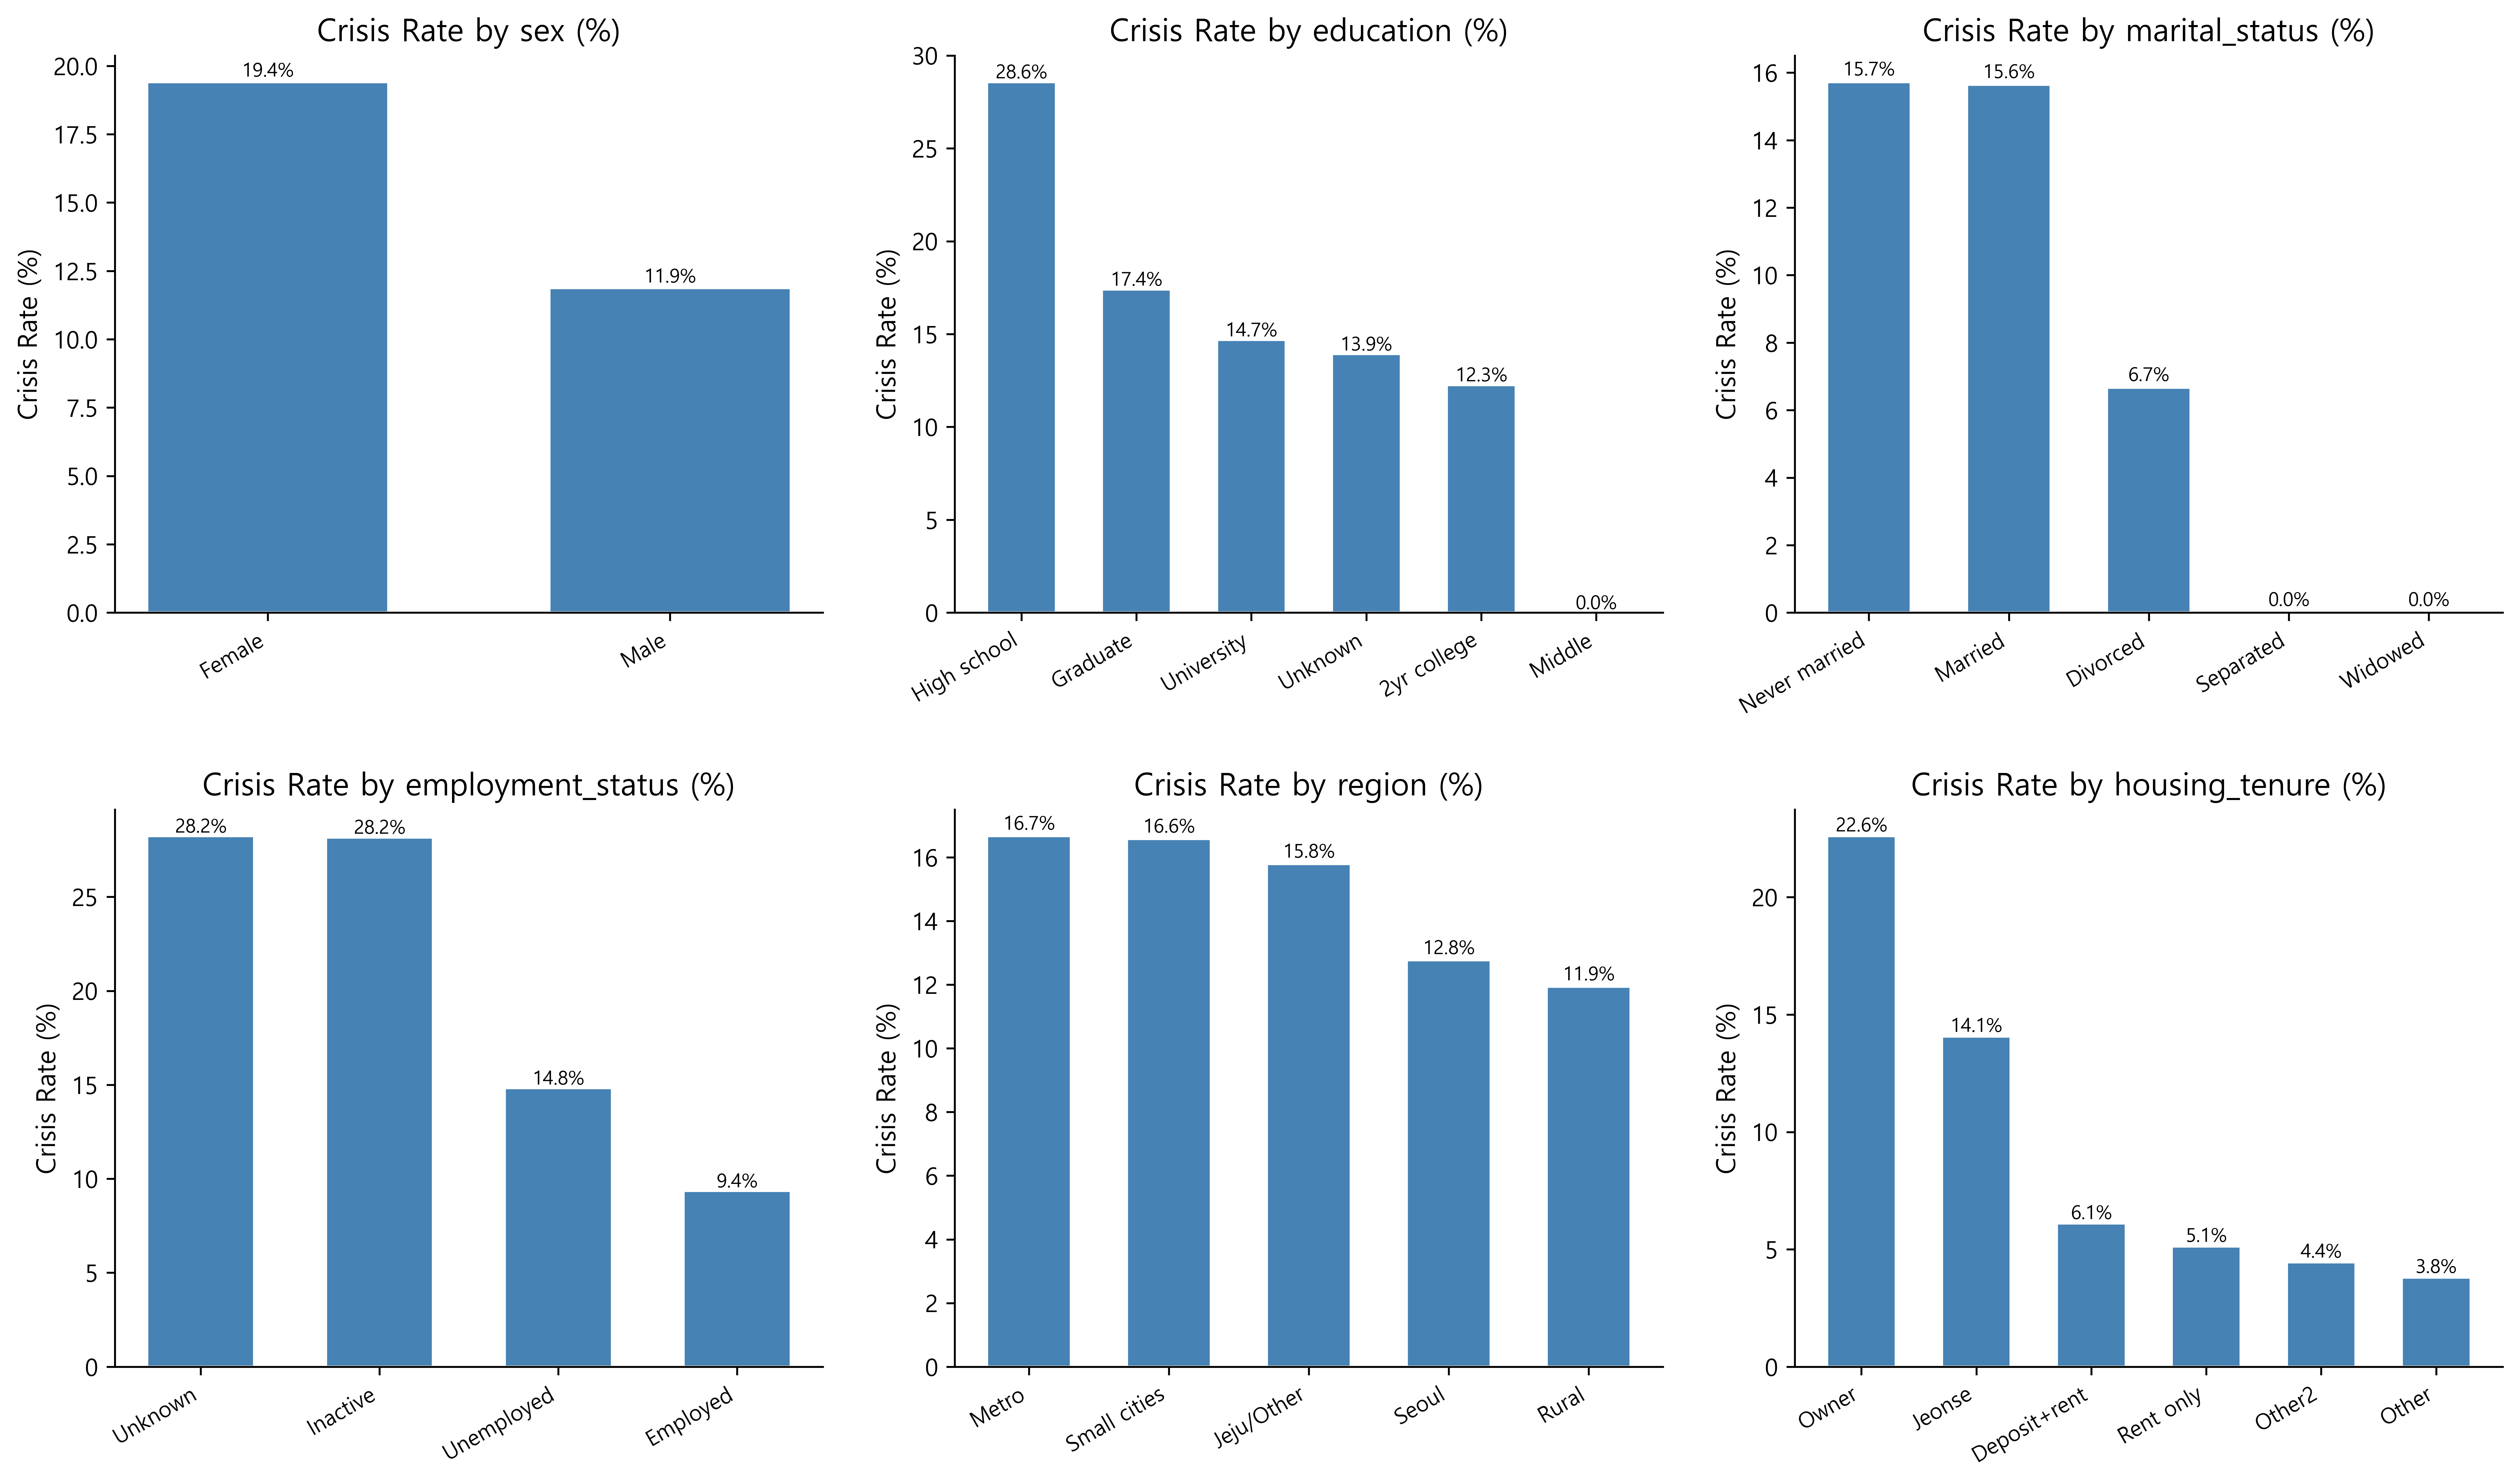

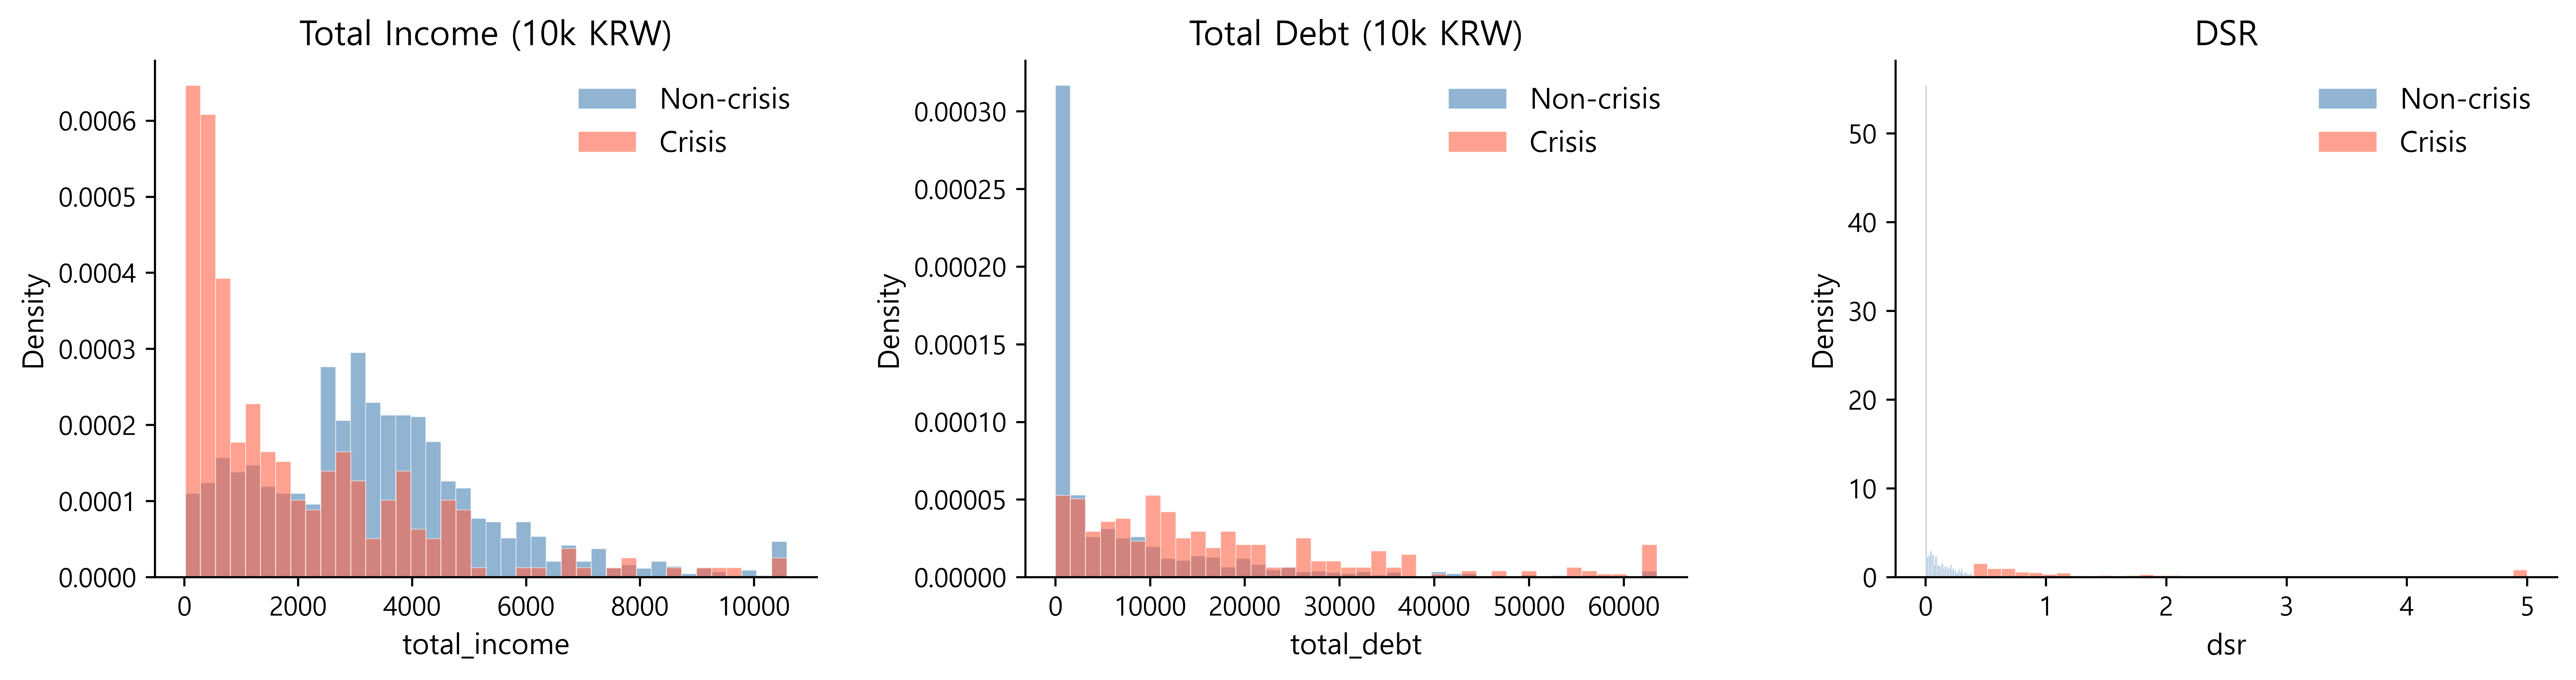

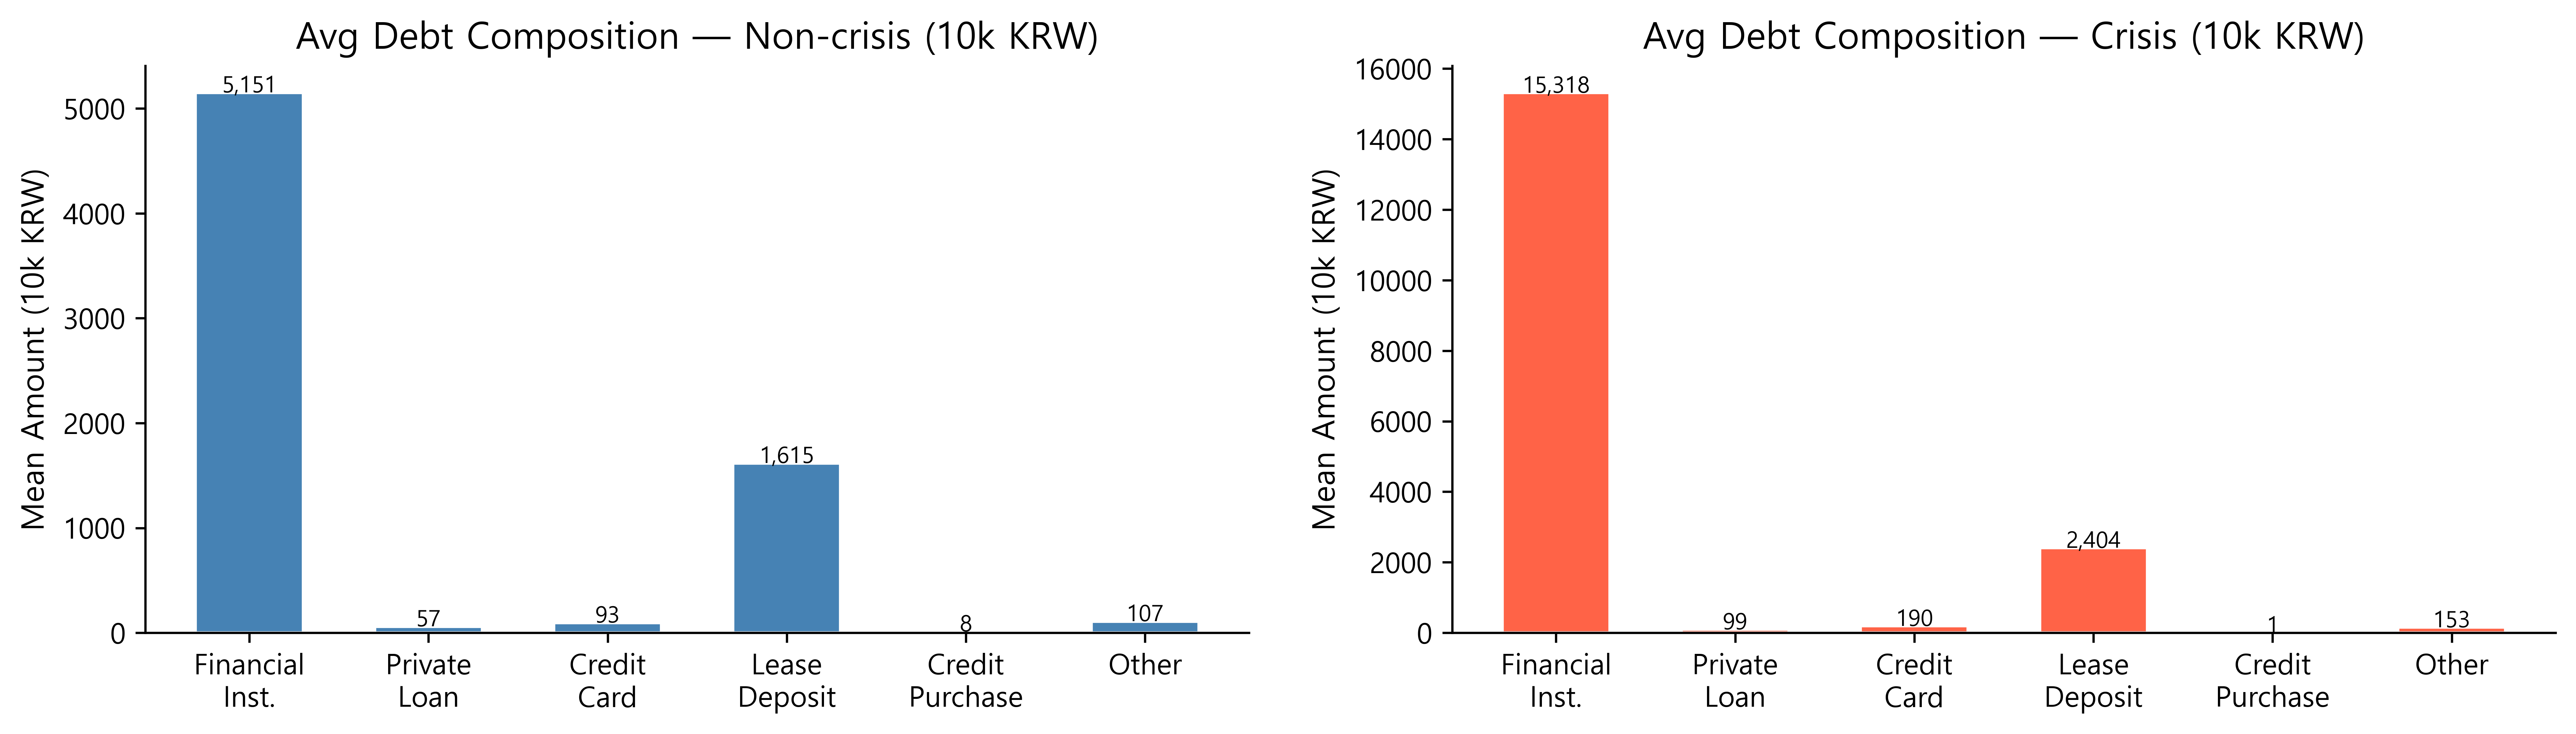

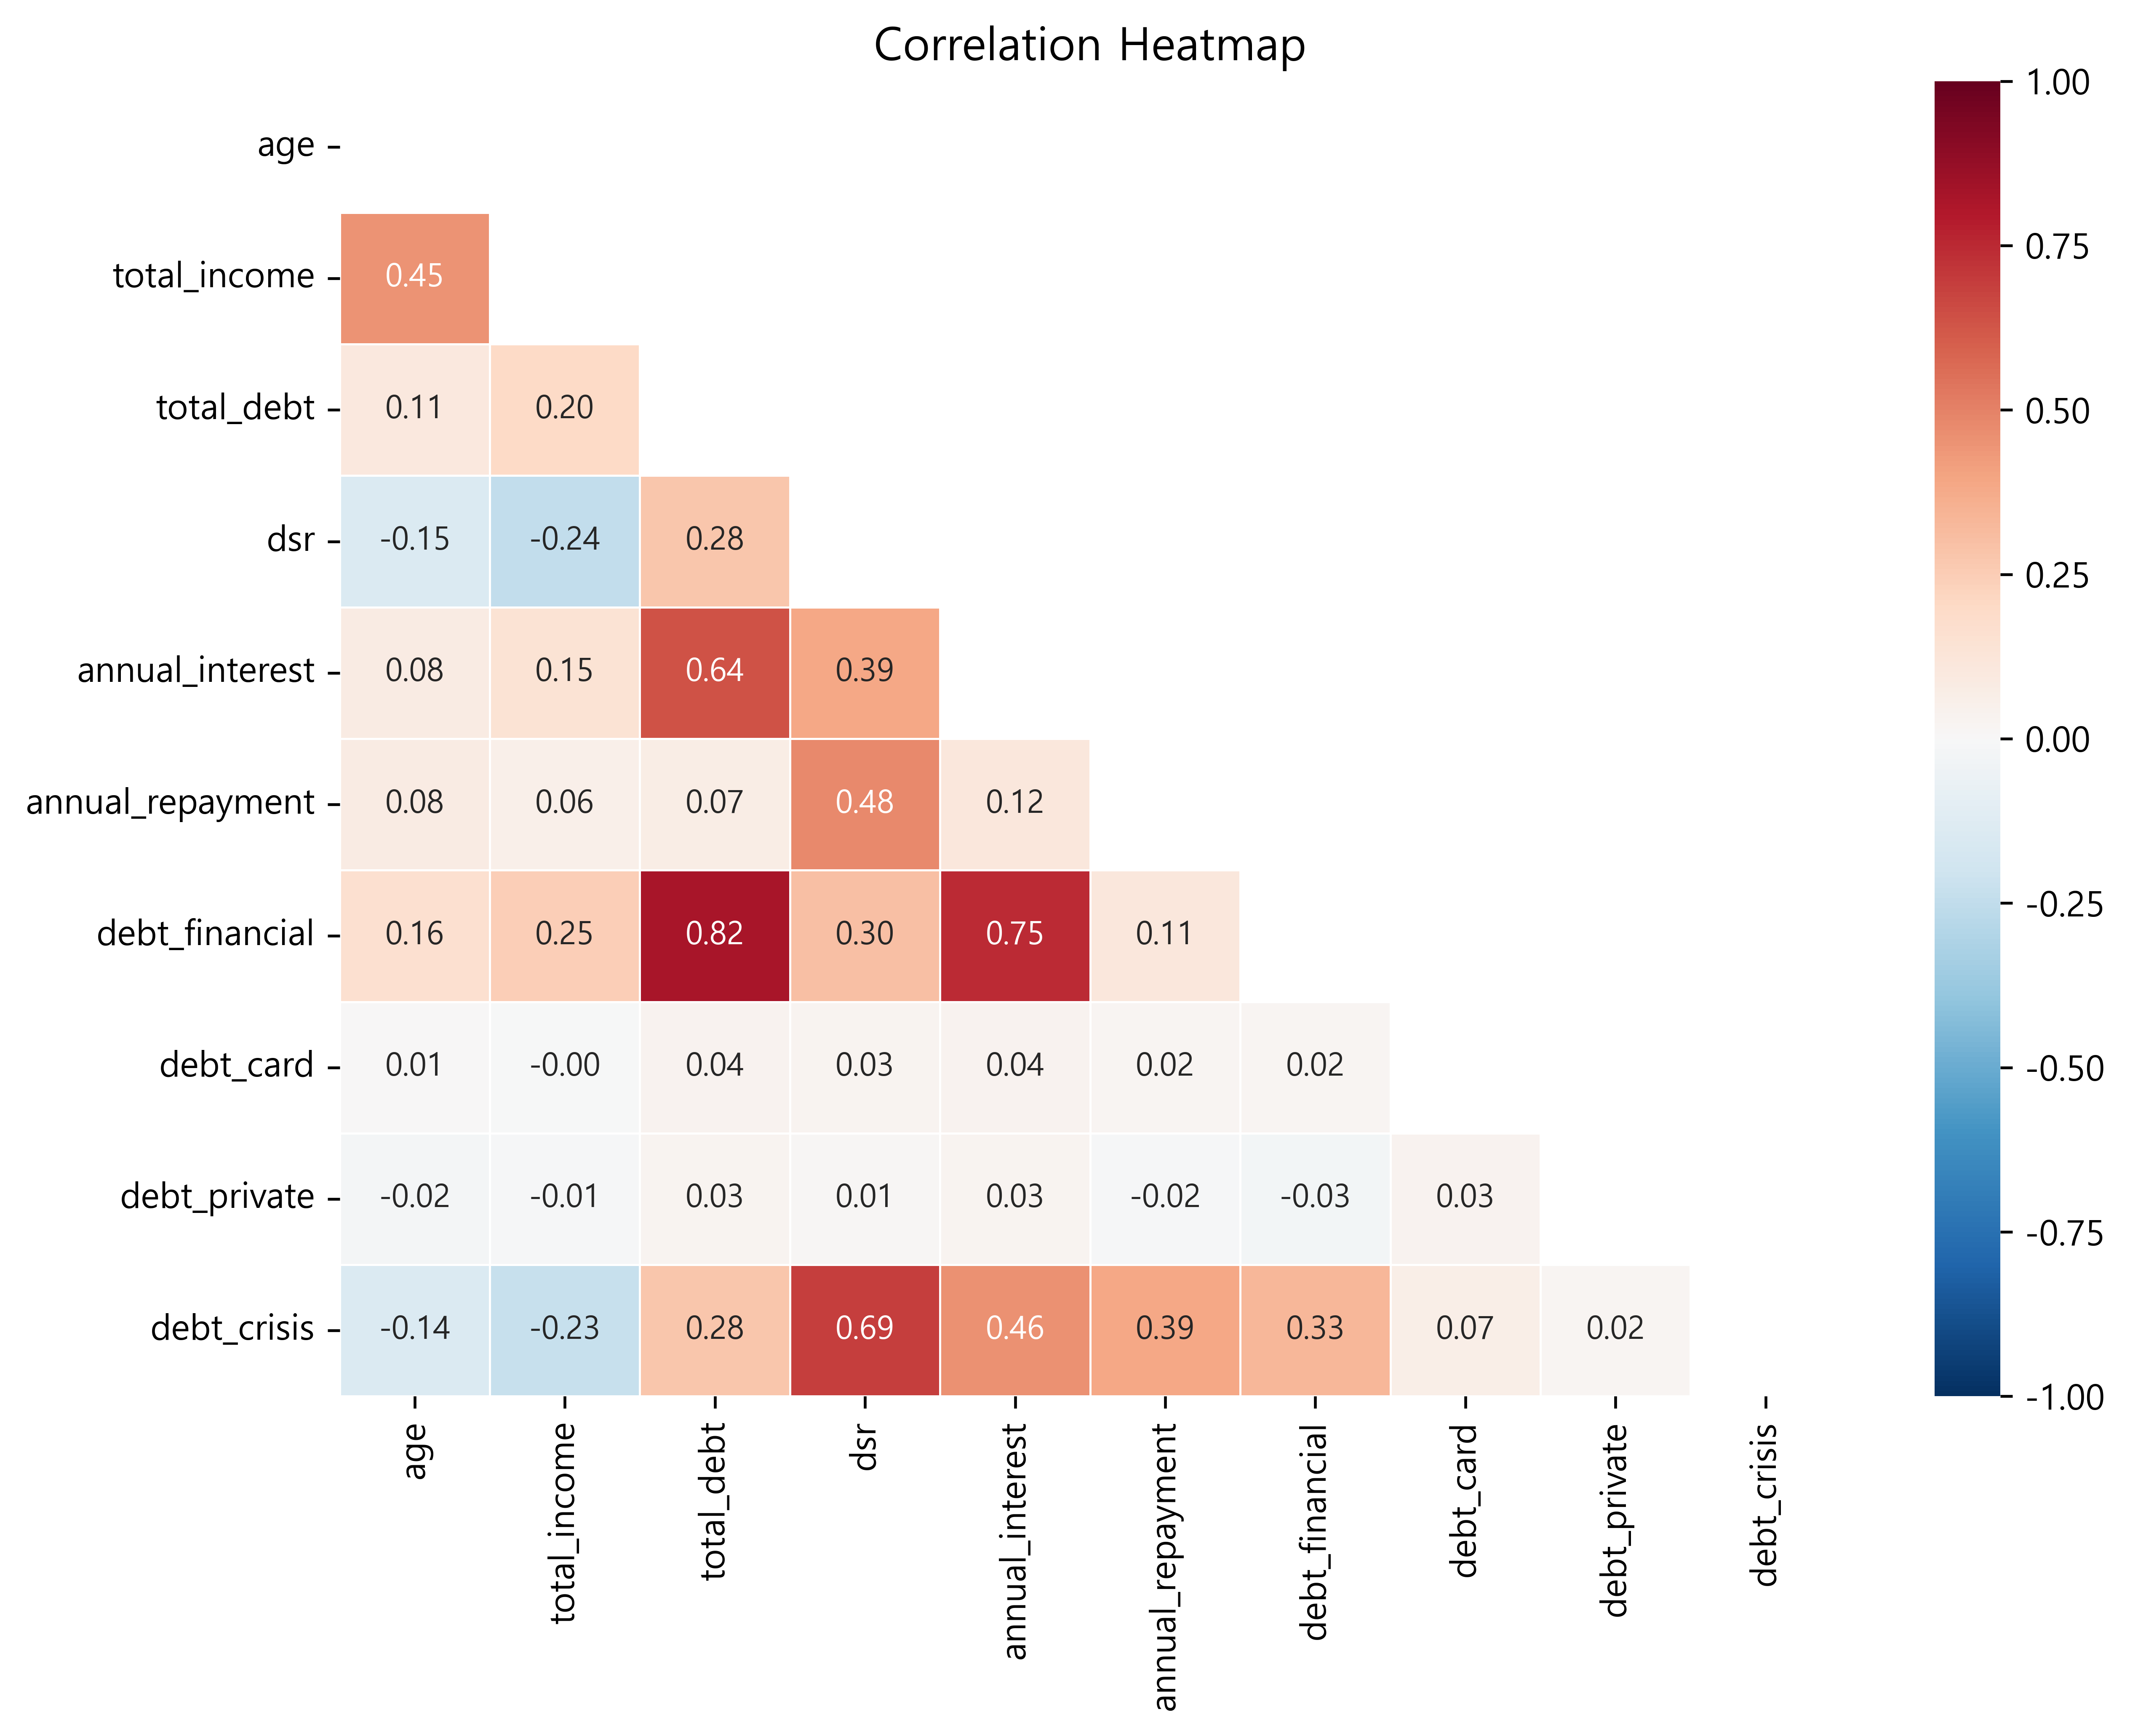

=== Missing value summary ===
                      missing_count  missing_pct
h19_pers_income5               1913         99.8
h19_pers_income3               1823         95.1
h19_pers_income2               1062         55.4
h19_pers_income1                916         47.8
p19_wgc                         489         25.5
employment_type                 421         22.0
h1906_aq2                       163          8.5
housing_debt_balance            163          8.5
h1906_10                        163          8.5


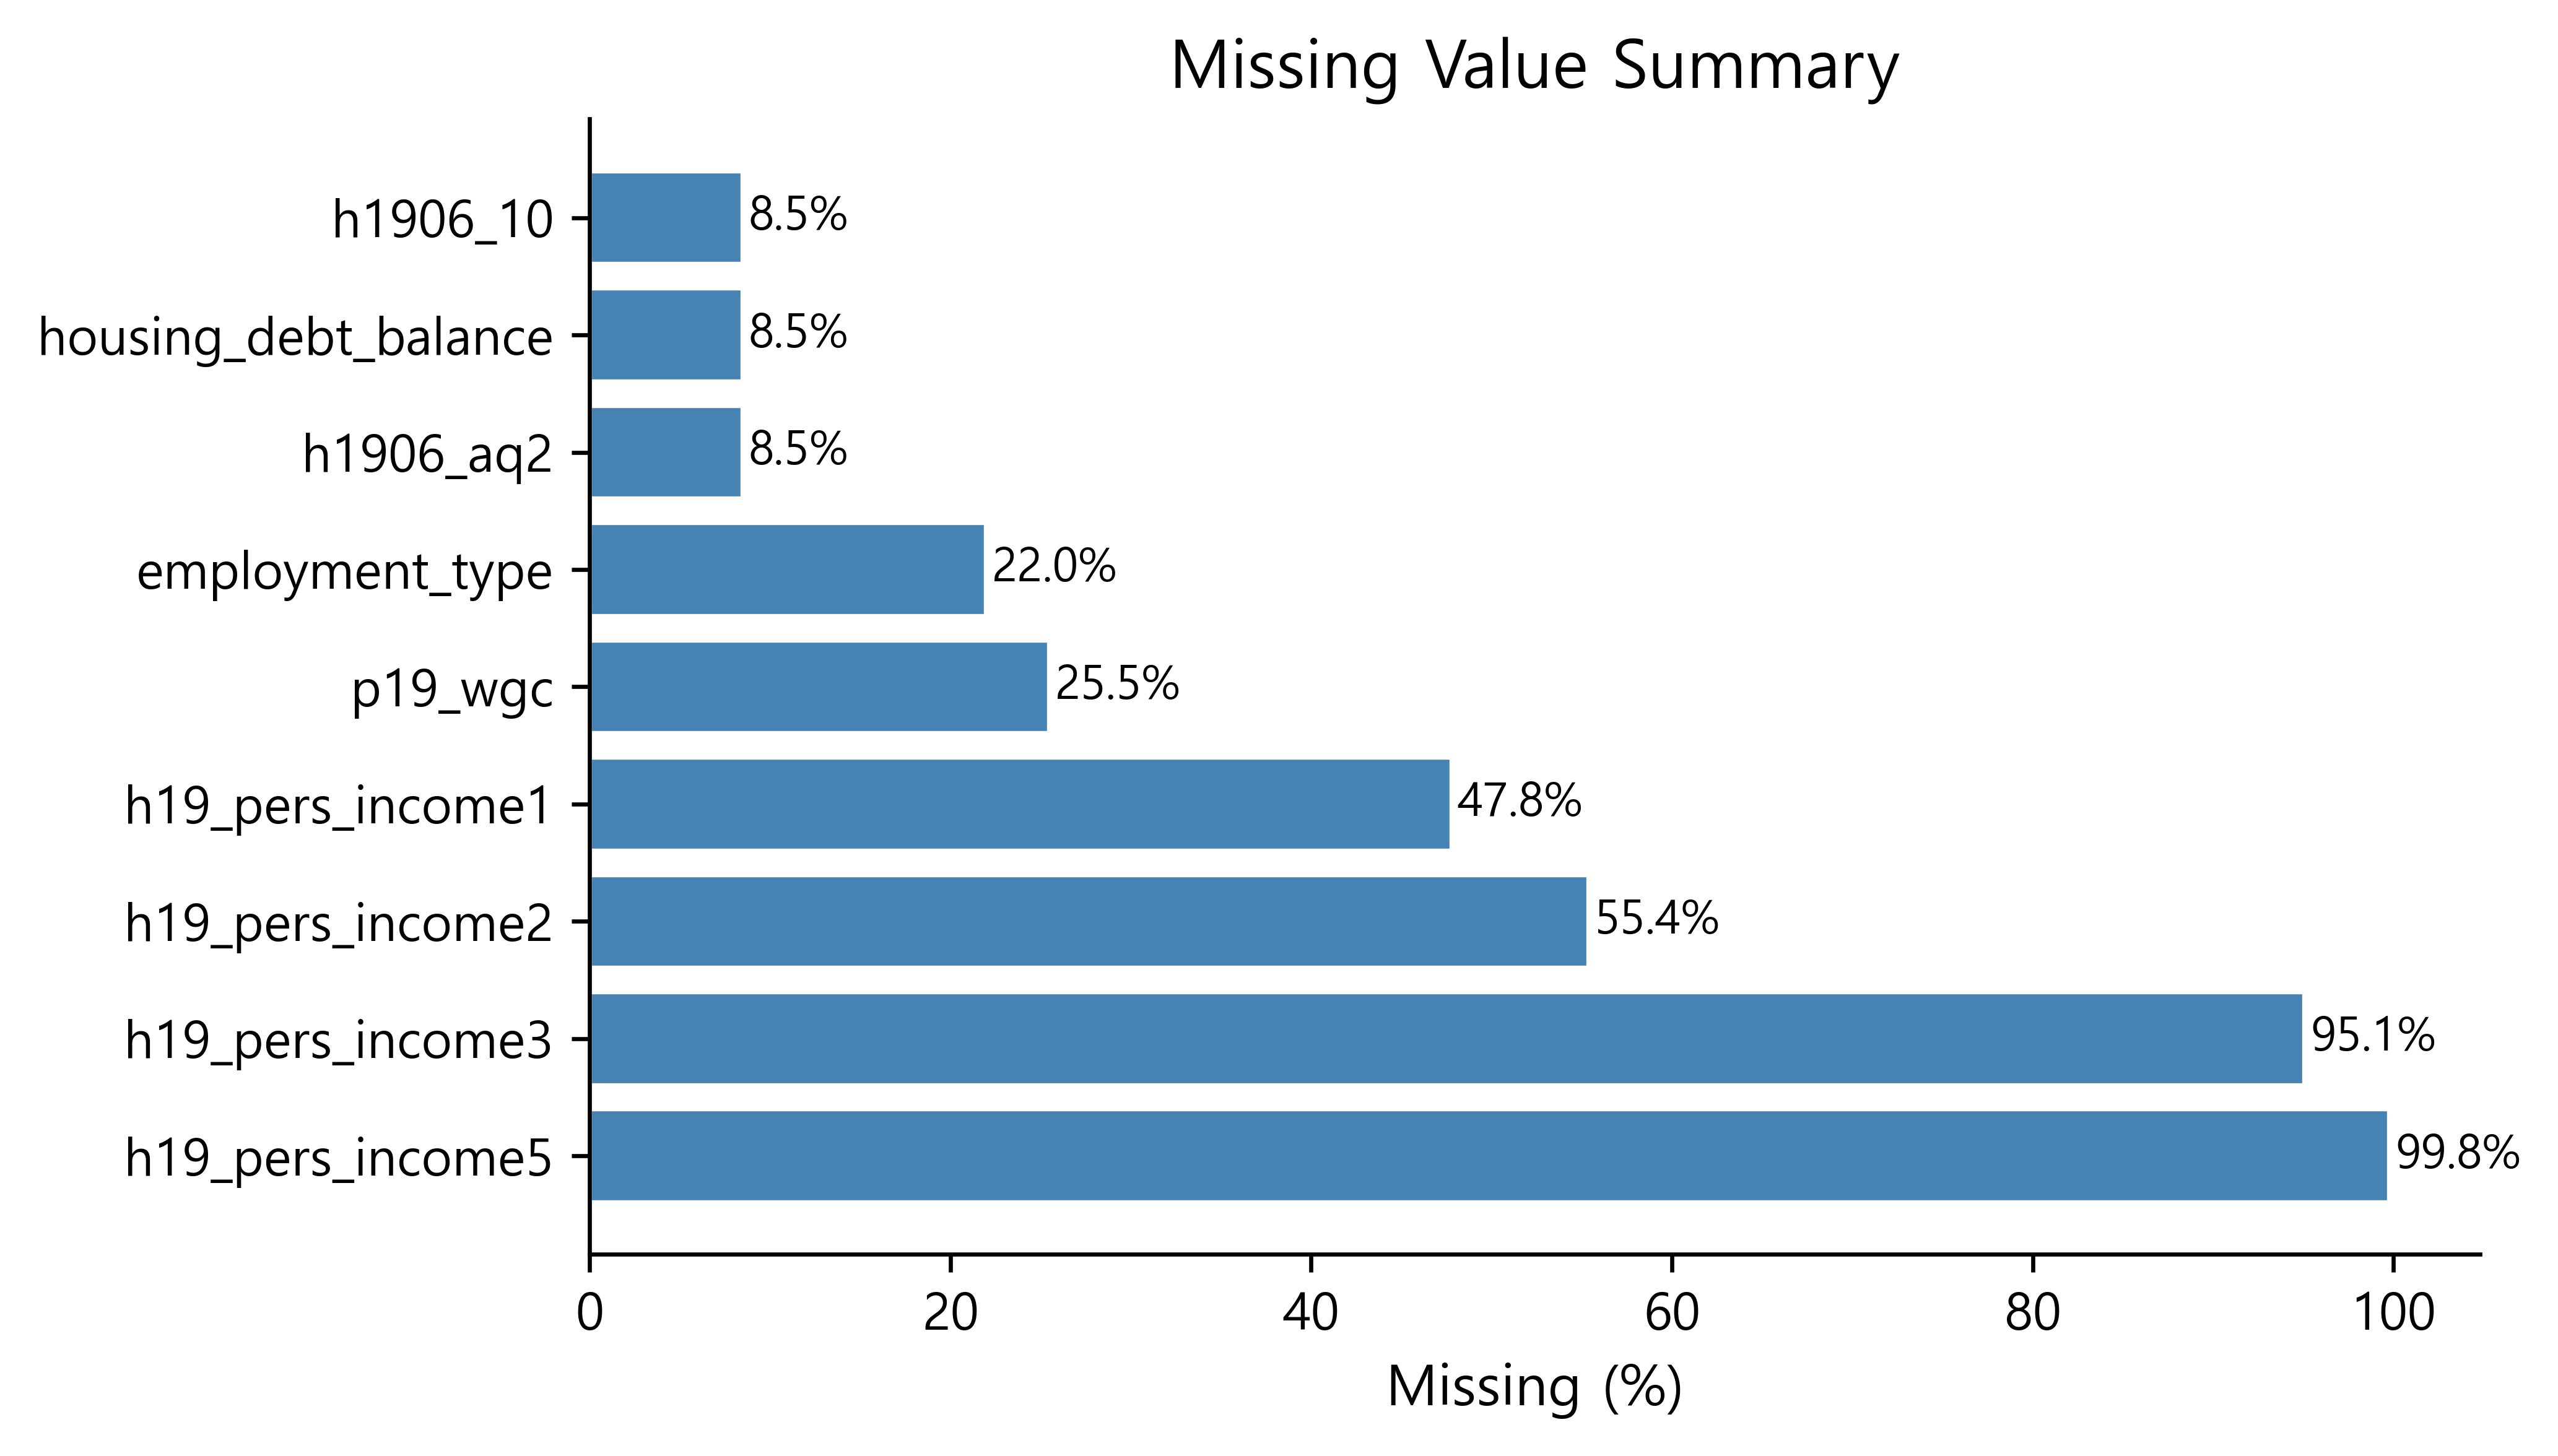

EDA summary saved -> outputs/eda_summary.csv
                n  age_mean  income_mean  debt_mean  dsr_mean
debt_crisis                                                  
0            1617     30.55      3409.59    7031.22      0.06
1             299     28.45      1908.33   18165.11      1.59


In [2]:
# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load preprocessed data
# ─────────────────────────────────────────────
df = pd.read_csv("../data/youth_debt_preprocessed.csv")

print(f"Shape : {df.shape}")


# ─────────────────────────────────────────────
# Cell 3 | Basic statistics by crisis group
# ─────────────────────────────────────────────
print("=== Descriptive stats by debt_crisis ===")
print(df.groupby('debt_crisis')[
    ['age', 'total_income', 'total_debt', 'dsr',
     'annual_interest', 'annual_repayment']
].mean().round(2))


# ─────────────────────────────────────────────
# Cell 4 | Target distribution
# ─────────────────────────────────────────────
counts = df['debt_crisis'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Non-crisis (0)', 'Crisis (1)'],
              counts.values,
              color=['steelblue', 'tomato'],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8,
            f'{val:,}\n({val/len(df):.1%})',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution')
ax.set_ylim(0, counts.max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/01_target_dist.png', **SAVE_KW)
plt.show()


# ─────────────────────────────────────────────
# Cell 5 | Age distribution by crisis
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for crisis, color, label in [(0,'steelblue','Non-crisis'), (1,'tomato','Crisis')]:
    axes[0].hist(df[df['debt_crisis']==crisis]['age'],
                 bins=20, alpha=0.6, color=color,
                 label=label, edgecolor='white', linewidth=0.3)
axes[0].set_title('Age Distribution by Crisis')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend(frameon=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

df['age_group'] = pd.cut(df['age'],
                          bins=[18,24,29,34,39],
                          labels=['19-24','25-29','30-34','35-39'])
crisis_by_age = df.groupby('age_group', observed=True)['debt_crisis'].mean() * 100

bars2 = axes[1].bar(crisis_by_age.index.astype(str),
                    crisis_by_age.values,
                    color='steelblue', edgecolor='white', width=0.5)
axes[1].set_title('Crisis Rate by Age Group (%)')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Crisis Rate (%)')
for bar, v in zip(bars2, crisis_by_age.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/02_age_dist.png', **SAVE_KW)
plt.show()


# ─────────────────────────────────────────────
# Cell 6 | Crisis rate by categorical variables
# ─────────────────────────────────────────────
cat_vars = {
    'sex'              : {1:'Male', 2:'Female'},
    'education'        : {1:'No schooling', 2:'Elementary', 3:'Middle',
                          4:'High school', 5:'2yr college',
                          6:'University', 7:'Graduate'},
    'marital_status'   : {1:'Married', 2:'Separated', 3:'Divorced',
                          4:'Widowed', 5:'Never married'},
    'employment_status': {1:'Employed', 2:'Unemployed', 3:'Inactive'},
    'region'           : {1:'Seoul', 2:'Metro', 3:'Small cities',
                          4:'Rural', 5:'Jeju/Other'},
    'housing_tenure'   : {1:'Owner', 2:'Jeonse', 3:'Deposit+rent',
                          4:'Rent only', 5:'Other', 6:'Other2'},
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (var, label_map) in enumerate(cat_vars.items()):
    if var not in df.columns:
        continue
    tmp = df.copy()
    tmp[var] = tmp[var].map(label_map).fillna('Unknown')
    crisis_rate = tmp.groupby(var)['debt_crisis'].mean() * 100
    crisis_rate = crisis_rate.sort_values(ascending=False)

    axes[idx].bar(range(len(crisis_rate)), crisis_rate.values,
                  color='steelblue', edgecolor='white', width=0.6)
    axes[idx].set_xticks(range(len(crisis_rate)))
    axes[idx].set_xticklabels(crisis_rate.index, rotation=30,
                               ha='right', fontsize=9)
    axes[idx].set_title(f'Crisis Rate by {var} (%)')
    axes[idx].set_ylabel('Crisis Rate (%)')
    for i, v in enumerate(crisis_rate.values):
        axes[idx].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=8)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/03_crisis_by_category.png', **SAVE_KW)
plt.show()


# ─────────────────────────────────────────────
# Cell 7 | Income & debt distribution by crisis
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

num_vars = ['total_income', 'total_debt', 'dsr']
titles   = ['Total Income (10k KRW)', 'Total Debt (10k KRW)', 'DSR']

for ax, var, title in zip(axes, num_vars, titles):
    cap = df[var].quantile(0.99)
    data0 = df[df['debt_crisis']==0][var].dropna().clip(upper=cap)
    data1 = df[df['debt_crisis']==1][var].dropna().clip(upper=cap)

    ax.hist(data0, bins=40, alpha=0.6, color='steelblue',
            label='Non-crisis', edgecolor='white',
            linewidth=0.3, density=True)
    ax.hist(data1, bins=40, alpha=0.6, color='tomato',
            label='Crisis', edgecolor='white',
            linewidth=0.3, density=True)
    ax.set_title(title)
    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/04_numeric_dist.png', **SAVE_KW)
plt.show()


# ─────────────────────────────────────────────
# Cell 8 | Debt composition by crisis
# ─────────────────────────────────────────────
debt_cols   = ['debt_financial','debt_private','debt_card',
               'debt_lease','debt_credit','debt_other']
debt_labels = ['Financial\nInst.','Private\nLoan','Credit\nCard',
               'Lease\nDeposit','Credit\nPurchase','Other']

debt_mean = df.groupby('debt_crisis')[debt_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, (crisis_val, title) in enumerate([(0,'Non-crisis'),(1,'Crisis')]):
    vals = debt_mean.loc[crisis_val].values
    color = 'steelblue' if crisis_val == 0 else 'tomato'
    bars = axes[i].bar(debt_labels, vals, color=color,
                       edgecolor='white', width=0.6)
    axes[i].set_title(f'Avg Debt Composition — {title} (10k KRW)')
    axes[i].set_ylabel('Mean Amount (10k KRW)')
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     v + 5, f'{v:,.0f}', ha='center', fontsize=8)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/05_debt_composition.png', **SAVE_KW)
plt.show()


# ─────────────────────────────────────────────
# Cell 9 | Correlation heatmap
# ─────────────────────────────────────────────
num_cols = ['age','total_income','total_debt','dsr',
            'annual_interest','annual_repayment',
            'debt_financial','debt_card','debt_private','debt_crisis']

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/06_correlation_heatmap.png', **SAVE_KW)
plt.show()


# ─────────────────────────────────────────────
# Cell 10 | Missing value summary
# ─────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct'  : missing_pct
})

print("=== Missing value summary ===")
print(missing_df)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(7, max(3, len(missing_df)*0.45)))
    ax.barh(missing_df.index, missing_df['missing_pct'],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Value Summary')
    for i, v in enumerate(missing_df['missing_pct']):
        ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../outputs/07_missing_values.png', **SAVE_KW)
    plt.show()


# ─────────────────────────────────────────────
# Cell 11 | Save EDA summary table
# ─────────────────────────────────────────────
summary = df.groupby('debt_crisis').agg(
    n           = ('debt_crisis','count'),
    age_mean    = ('age','mean'),
    income_mean = ('total_income','mean'),
    debt_mean   = ('total_debt','mean'),
    dsr_mean    = ('dsr','mean'),
).round(2)

summary.to_csv('../outputs/eda_summary.csv', encoding='utf-8-sig')
print("EDA summary saved -> outputs/eda_summary.csv")
print(summary)